In [1]:
import pandas as pd

# Load data
df = pd.read_csv("D:\\New folder\\Cars_data (1).csv")

# Clean numeric columns with commas and strings at the end (e.g., "10,000 km", "15.5 L", "100 bhp")
numeric_cols = ["price", "km_driven", "mileage_new", "max_engine_capacity_new"]
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)  # Ensure all values are strings
        .str.replace(",", "", regex=False)  # Remove commas
        .str.extract(r"([0-9.]+)")  # Extract numeric part using regex
        .squeeze()  # Convert DataFrame to Series if needed
        .astype(float)  # Convert to float
    )

# Verify the cleaned columns
print(df[numeric_cols].head())


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
      price  km_driven  mileage_new  max_engine_capacity_new
0  950000.0   150000.0        12.99                   2494.0
1  500000.0    53755.0        15.10                   2179.0
2  738000.0    53838.0        18.53                   1199.0
3  850000.0    28112.0        15.80                   1591.0
4  899999.0    63125.0        24.52                   1248.0


In [2]:
# Example: "100.6bhp@3600rpm" → 100.6
df["max_power"] = df["Max Power"].str.extract(r"(\d+\.\d+|\d+)").astype(float)
df["max_torque"] = df["Max Torque"].str.extract(r"(\d+\.\d+|\d+)").astype(float)


In [3]:
# Drop rows with missing price
df.dropna(subset=["price"], inplace=True)

# Fill missing values
df["mileage_new"].fillna(df["mileage_new"].median())

0        12.99
1        15.10
2        18.53
3        15.80
4        24.52
         ...  
34028    17.42
34029    27.39
34030    18.60
34031    18.60
34032    21.21
Name: mileage_new, Length: 34033, dtype: float64

In [4]:
df["max_power"].fillna(df["max_power"].median())
df["max_torque"].fillna(df["max_torque"].median())

0        200.0
1        330.0
2        113.0
3        151.0
4        200.0
         ...  
34028    320.0
34029    190.0
34030    114.7
34031    114.7
34032    113.0
Name: max_torque, Length: 34033, dtype: float64

In [5]:
# Remove rows where 'max_engine_capacity_new' is equal to 0
df = df[df['max_engine_capacity_new'] != 0]

In [6]:
import numpy as np

# Define columns to check for outliers
log_cols = ['max_power', 'max_torque', 'max_engine_capacity_new', 'price']

# For each column, remove rows where the value is outside 1.5*IQR from Q1 or Q3
for col in log_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [7]:
import numpy as np

df["log_max_power"] = np.log(df["max_power"])
df["log_max_torque"] = np.log(df["max_torque"])
df["log_max_engine_capacity_new"] = np.log(df["max_engine_capacity_new"])


In [8]:
import numpy as np

features = [
    
 "km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
 "log_max_engine_capacity_new"

]

df = df.dropna(subset=["price"])
df = df.dropna(subset=features)
X = df[features]
y = df["price"]
#y = np.log(df["price"])  # Natural logarithm (base e)

In [9]:
# Identify negative values in 'max_engine_capacity_new'
neg_values = df[df['max_engine_capacity_new'] < 0]
print("Rows with negative 'max_engine_capacity_new':")
print(neg_values[['max_engine_capacity_new']])
print(f"Total negative values: {len(neg_values)}")

Rows with negative 'max_engine_capacity_new':
Empty DataFrame
Columns: [max_engine_capacity_new]
Index: []
Total negative values: 0


In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


X_train, X_val = train_test_split(X,test_size=0.2,random_state=44,shuffle=True)
y_train, y_val = train_test_split(y,test_size=0.2,random_state=44,shuffle=True)



scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


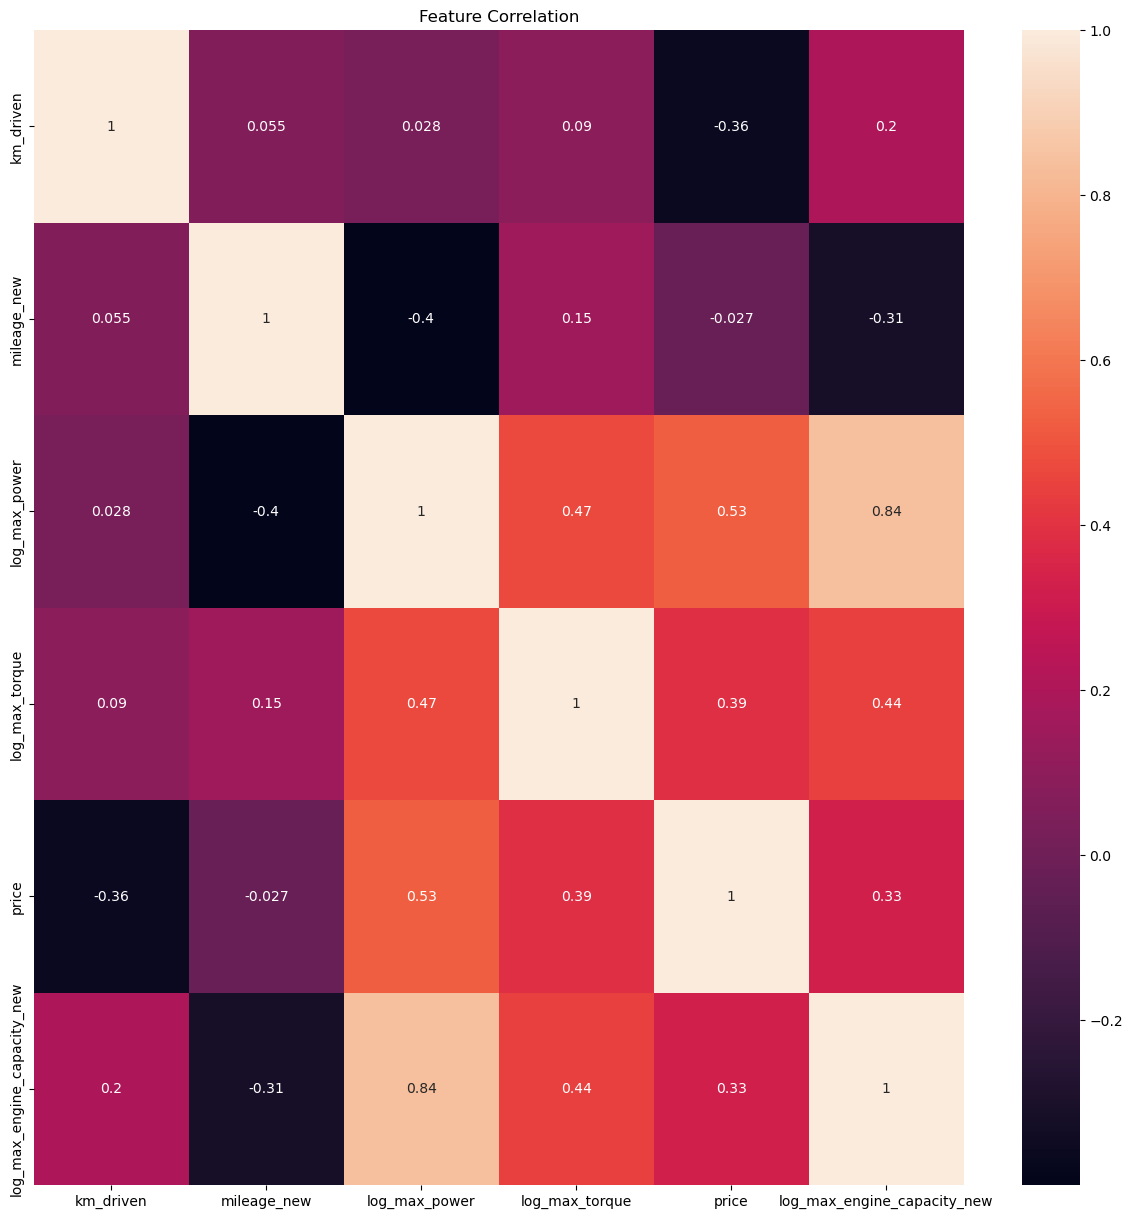

In [11]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

plt.figure(figsize=(15, 15))

sns.heatmap(df[[
"km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
 "log_max_engine_capacity_new"
]].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

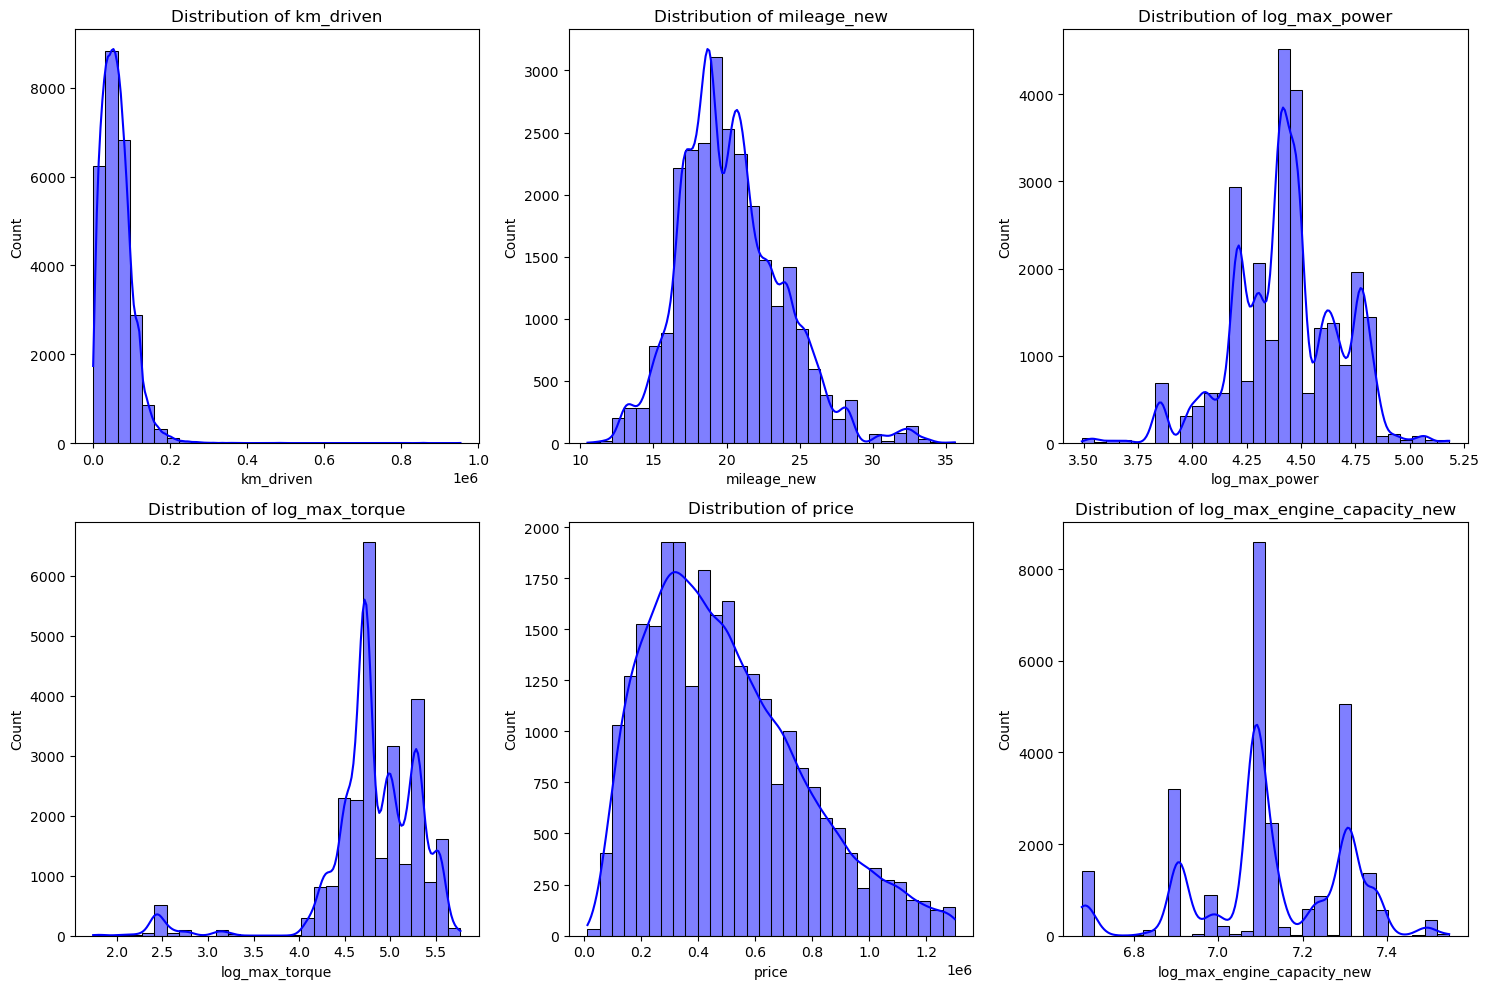

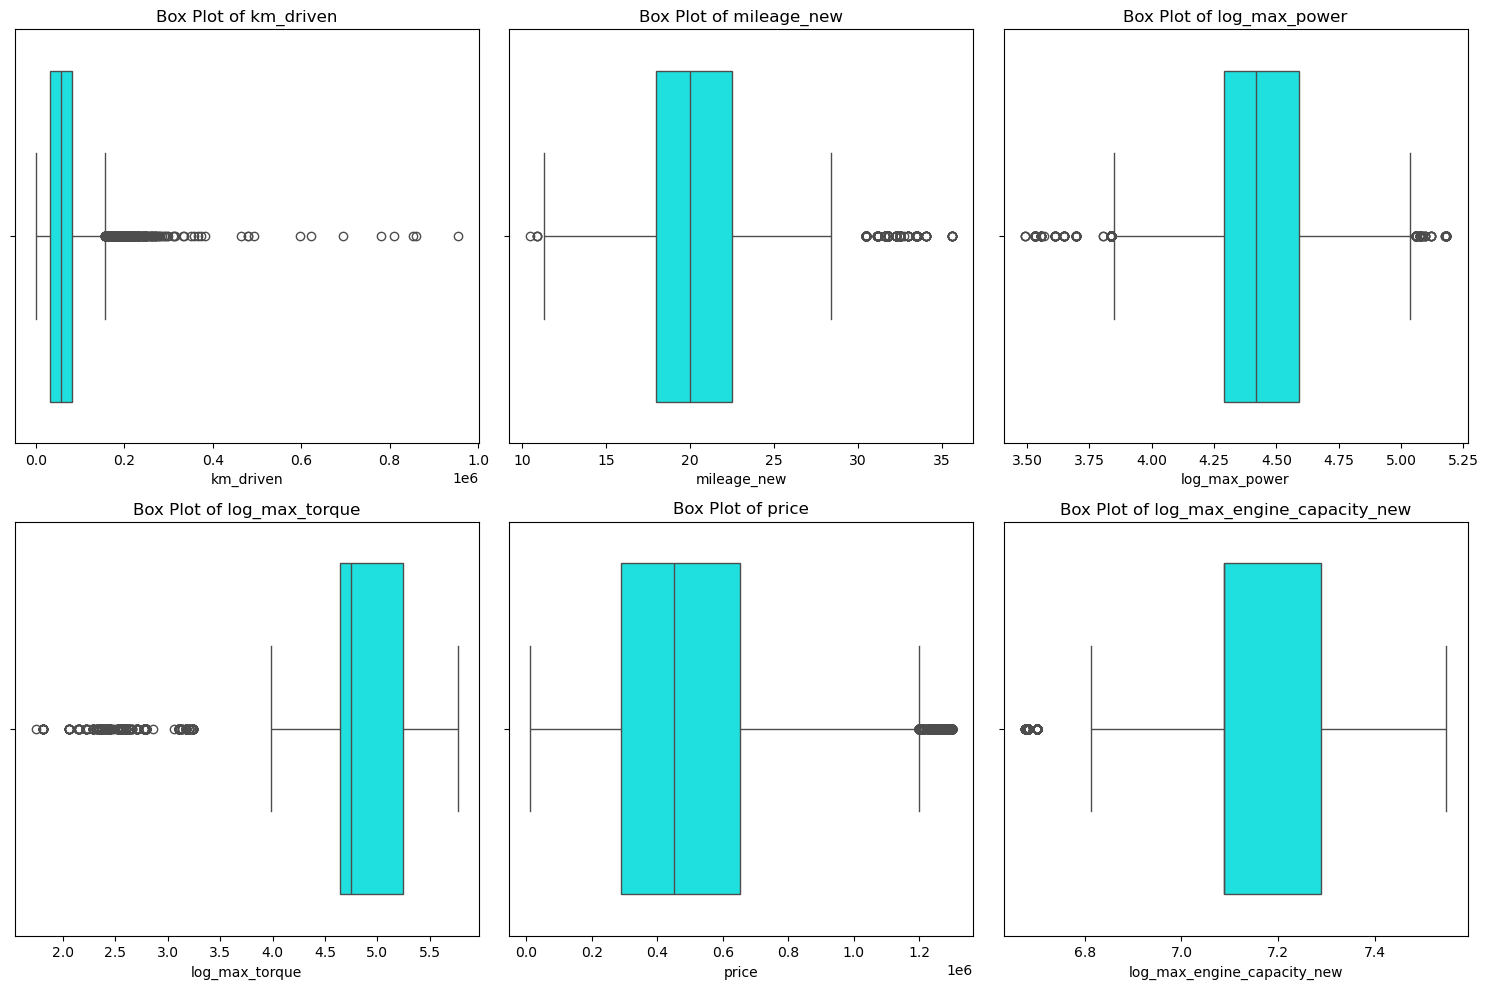

In [12]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "log_max_power", "log_max_torque", "price",
    "log_max_engine_capacity_new"
]

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model1 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model1.summary()
model1.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,537 (68.50 KB)

 Trainable params: 17,537 (68.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model1.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

Epoch 1/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 315634089984.0000 - mae: 493010.0625 - val_loss: 300883935232.0000 - val_mae: 480332.1250
Epoch 2/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 294352945152.0000 - mae: 472768.4688 - val_loss: 242436767744.0000 - val_mae: 418970.4062
Epoch 3/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 221796368384.0000 - mae: 392618.7812 - val_loss: 128756187136.0000 - val_mae: 276247.9375
Epoch 4/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 101492195328.0000 - mae: 239399.2188 - val_loss: 49044103168.0000 - val_mae: 177163.7031
Epoch 5/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 49290096640.0000 - mae: 179355.0000 - val_loss: 45164060672.0000 - val_mae: 172524.5625
Epoch 6/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 46036205568.0000 - mae: 174441.2812 - val_loss: 41817219072.0000 - val_mae: 166025.1094
Epoch 7/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 42152112128.0000 - mae: 165872.4062 - 

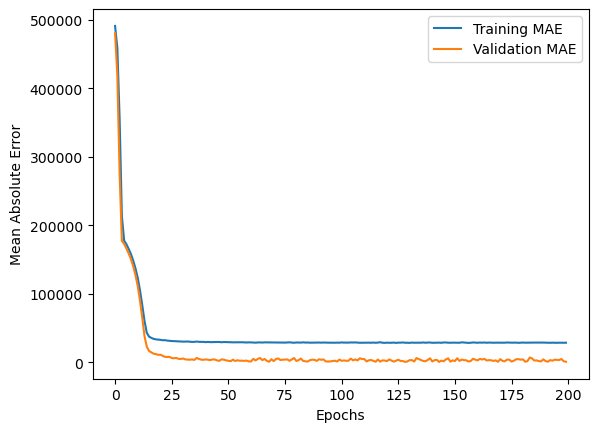

In [15]:
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

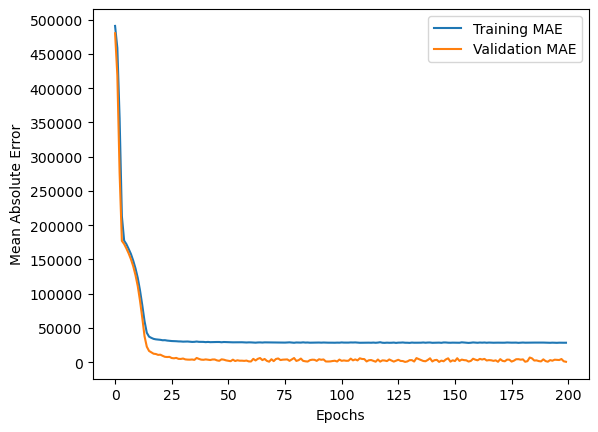

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model2 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model2.summary()
model2.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,537 (68.50 KB)

 Trainable params: 17,537 (68.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model2.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 313087787008.0000 - mae: 491963.0000 - val_loss: 263418593280.0000 - val_mae: 441950.3125
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 223171313664.0000 - mae: 394788.3438 - val_loss: 93984759808.0000 - val_mae: 229471.1719
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 75079335936.0000 - mae: 206012.5625 - val_loss: 47792418816.0000 - val_mae: 175511.9844
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 48429838336.0000 - mae: 177607.5938 - val_loss: 45042565120.0000 - val_mae: 172439.3438
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45510770688.0000 - mae: 172911.5781 - val_loss: 42410160128.0000 - val_mae: 167406.2656
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 43301576704.0000 - mae: 168593.1875 - val_loss: 39464972288.0000 - val_mae: 161417.9531
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 39578976256.0000 - mae: 161326.6406 - val_loss: 3

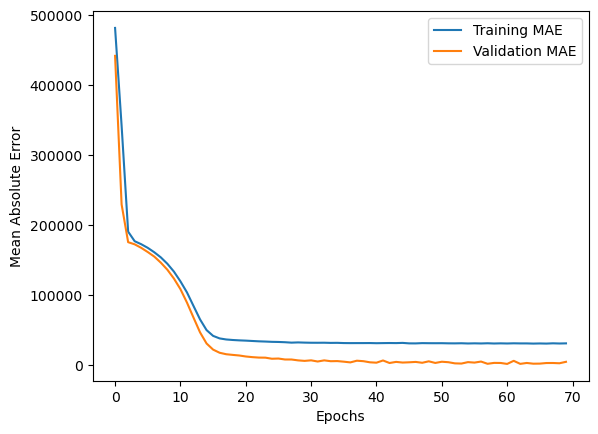

In [19]:
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

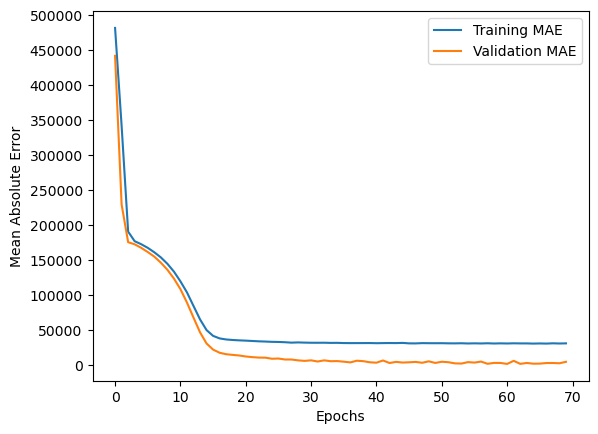

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model3 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.1),

    Dense(1)
])
model3.summary()
model3.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,729 (100.50 KB)

 Trainable params: 25,729 (100.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 257616445440.0000 - mae: 427765.9688 - val_loss: 44174884864.0000 - val_mae: 171370.7500
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 43200421888.0000 - mae: 168029.3438 - val_loss: 30519177216.0000 - val_mae: 142241.3906
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 27619753984.0000 - mae: 133527.3906 - val_loss: 10437829632.0000 - val_mae: 82736.8672
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9415563264.0000 - mae: 75339.3672 - val_loss: 1026697152.0000 - val_mae: 24626.0742
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3707114240.0000 - mae: 46230.8086 - val_loss: 480782144.0000 - val_mae: 15859.2012
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3184603904.0000 - mae: 42017.2383 - val_loss: 379449088.0000 - val_mae: 13872.3369
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2936623104.0000 - mae: 40087.8086 - val_loss: 250727168.0000 - val

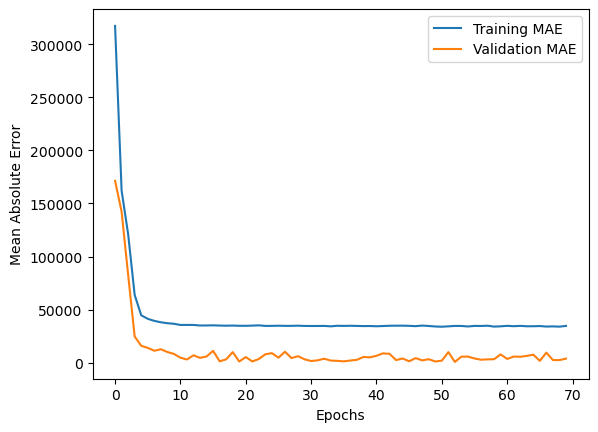

In [22]:
history = model3.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

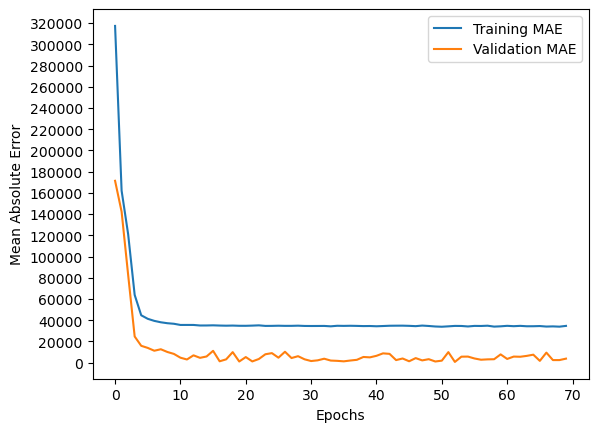

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model4 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(127, activation="relu"),
    Dropout(0.1),
    Dense(64, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model4.summary()
model4.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 127)            │        32,639 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 127)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,808 (686.75 KB)

 Trainable params: 175,808 (686.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 162812280832.0000 - mae: 310825.4062 - val_loss: 2806081792.0000 - val_mae: 42125.7422
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3153033728.0000 - mae: 42281.9180 - val_loss: 208984272.0000 - val_mae: 10449.5938
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2200178176.0000 - mae: 34110.2695 - val_loss: 50466644.0000 - val_mae: 5097.4043
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2108333824.0000 - mae: 32806.6719 - val_loss: 23865254.0000 - val_mae: 3717.5623
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2069504768.0000 - mae: 32246.7988 - val_loss: 115797048.0000 - val_mae: 10182.4531
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2102697600.0000 - mae: 32523.1738 - val_loss: 77084096.0000 - val_mae: 8482.6426
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2055276544.0000 - mae: 32168.8867 - val_loss: 256737968.0000 - val_mae: 15027.2803
E

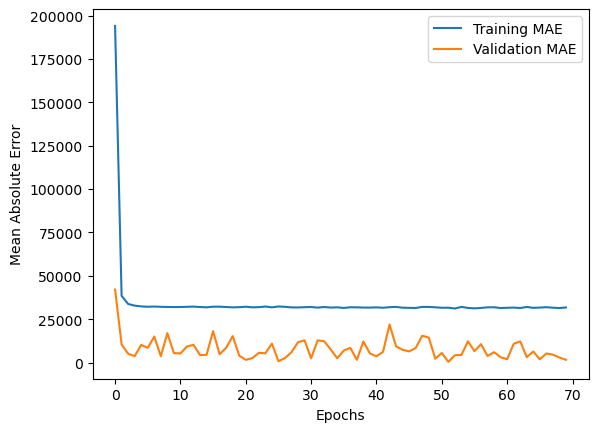

In [25]:
history = model4.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

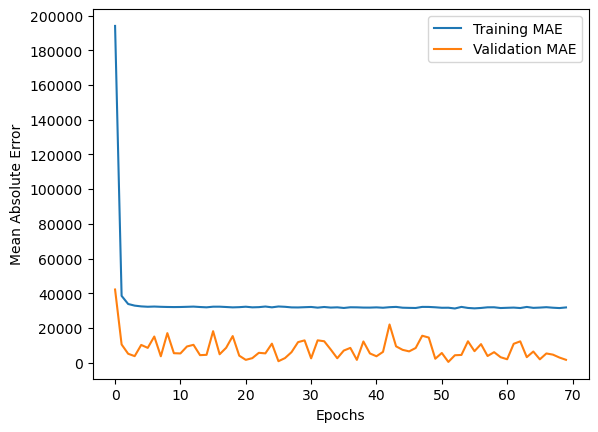

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model5 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(1)
])
model5.summary()
model5.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,481 (455.00 KB)

 Trainable params: 116,481 (455.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 158352441344.0000 - mae: 305180.5312 - val_loss: 1056485696.0000 - val_mae: 25894.5020
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3536211456.0000 - mae: 44084.1992 - val_loss: 123779056.0000 - val_mae: 8272.4736
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3343949568.0000 - mae: 41217.9414 - val_loss: 1796824704.0000 - val_mae: 39983.9102
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3173818624.0000 - mae: 39958.2539 - val_loss: 120679528.0000 - val_mae: 10205.3174
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3073080576.0000 - mae: 39485.4688 - val_loss: 34546468.0000 - val_mae: 4786.4570
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3085880320.0000 - mae: 39607.1719 - val_loss: 92591944.0000 - val_mae: 9242.3359
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3035681536.0000 - mae: 39720.1367 - val_loss: 488272288.0000 - val_mae: 20232.8984

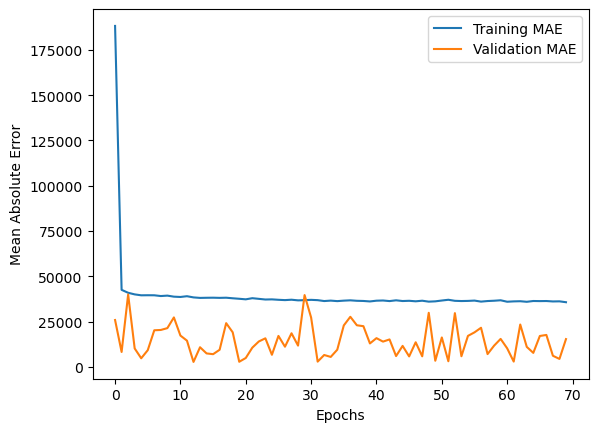

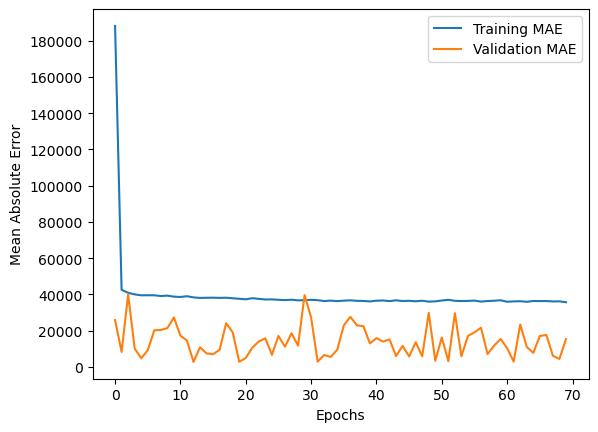

In [28]:

history = model5.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model6 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model6.summary()
model6.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,049 (133.00 KB)

 Trainable params: 34,049 (133.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 281239060480.0000 - mae: 454571.9375 - val_loss: 46561275904.0000 - val_mae: 174623.3750
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 45287288832.0000 - mae: 171653.8125 - val_loss: 29284442112.0000 - val_mae: 139533.1719
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 24850956288.0000 - mae: 126261.9766 - val_loss: 2899826176.0000 - val_mae: 43015.6094
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4015374848.0000 - mae: 47520.4570 - val_loss: 437107168.0000 - val_mae: 16007.5449
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2757557248.0000 - mae: 38247.8789 - val_loss: 138822384.0000 - val_mae: 8454.1152
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2588512000.0000 - mae: 36758.4883 - val_loss: 91197008.0000 - val_mae: 7014.6094
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2457436160.0000 - mae: 35437.2344 - val_loss: 86553464.0000 - val_mae: 

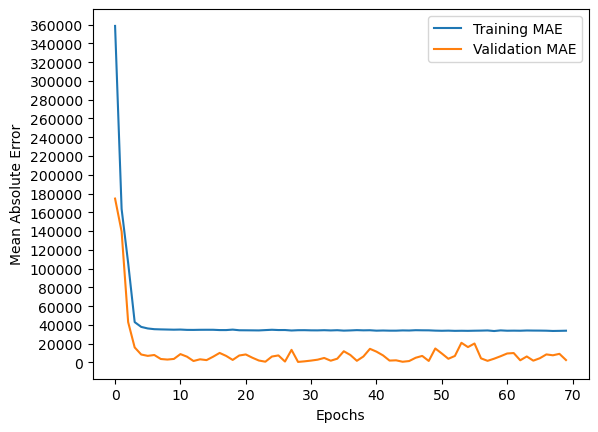

In [30]:
history = model6.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model6 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model6.summary()
model6.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,049 (133.00 KB)

 Trainable params: 34,049 (133.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model6.fit(X_train, y_train, epochs=200,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

Epoch 1/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 288540917760.0000 - mae: 462885.5625 - val_loss: 47618396160.0000 - val_mae: 176612.2969
Epoch 2/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45902557184.0000 - mae: 173495.5156 - val_loss: 31171094528.0000 - val_mae: 144138.5469
Epoch 3/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 26708574208.0000 - mae: 131305.7656 - val_loss: 4127750400.0000 - val_mae: 51707.5781
Epoch 4/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3686177536.0000 - mae: 46291.1523 - val_loss: 245292224.0000 - val_mae: 11293.3164
Epoch 5/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2086510208.0000 - mae: 33317.1055 - val_loss: 135850352.0000 - val_mae: 8682.6553
Epoch 6/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1942057344.0000 - mae: 31372.7129 - val_loss: 66206288.0000 - val_mae: 6252.4658
Epoch 7/200
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1843124352.0000 - mae: 30706.3105 - val_loss: 33940508.0000 - va

In [ ]:
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "log_max_power", "log_max_torque", "price",
    "log_max_engine_capacity_new"
]



# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model7 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model7.summary()
model7.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()